In [1]:
from google.colab import drive
drive.mount('/content/drive')
%env PKG_DIR=/content/drive/MyDrive/ARTM/topic-modelling-attention

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
env: PKG_DIR=/content/drive/MyDrive/ARTM/topic-modelling-attention


In [7]:
#!git clone https://github.com/knagaev/topic-modelling-attention.git
%cd /content/drive/MyDrive/ARTM/topic-modelling-attention
!git pull https://github.com/knagaev/topic-modelling-attention.git

/content/drive/MyDrive/ARTM/topic-modelling-attention
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 8 (delta 5), reused 8 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 87.77 KiB | 178.00 KiB/s, done.
From https://github.com/knagaev/topic-modelling-attention
 * branch            HEAD       -> FETCH_HEAD
Updating a06a976..38ab45f
Fast-forward
 filtered_phi_hist_perplexity.txt |    0
 filtered_phi_hist_vocab.json     |  399 ++++++++++++
 main_orig.py                     |   15 +-
 phi_hist.ipynb                   | 1262 ++++++++------------------------------
 src/cartm/model_base.py          |    7 +-
 5 files changed, 651 insertions(+), 1032 deletions(-)
 create mode 100644 filtered_phi_hist_perplexity.txt
 create mode 100644 filtered_phi_hist_vocab.json


In [8]:
#!pip install /content/topic-modelling-attention/
#!pip install uv
!uv pip install -e $PKG_DIR
#!uv pip install --system --upgrade jax jaxlib
#!uv pip install --upgrade "jax-cuda12-plugin==0.10.0"

Using Python 3.12.13 environment at: /usr
Resolved 53 packages in 576ms
⠙ Preparing packages... (0/1)                                                   warning: `build_system.requires = ["uv-build>=0.9.13,<0.10.0"]` does not contain the
                        current uv version 0.11.2
Prepared 1 package in 28ms
Uninstalled 1 package in 0.52ms
Installed 1 package in 8ms
 ~ cartm==0.1.0 (from file:///content/drive/MyDrive/ARTM/topic-modelling-attention)


In [9]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [39]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import ast
import json

import jax
import jax.numpy as jnp
from jax import Array

from nltk.stem import WordNetLemmatizer

from sklearn.datasets import fetch_20newsgroups
from sklearn.decomposition import LatentDirichletAllocation

import matplotlib.pyplot as plt
import seaborn as sns

from cartm import ContextTopicModel, AttentiveTopicModel
from cartm.preprocessing import (
    CorpusLoader,
    BatchedCorpusLoader,
    build_bow,
)
from cartm.metrics import (
    PerplexityMetric,
    NPMICoherenceMetric,
    SparsityMetric,
    TopicVarianceMetric,
)
from cartm.regularization import DecorrelationRegularization


In [27]:

data = fetch_20newsgroups(data_home='./data/', subset='all').data

#categories = ['alt.atheism', 'talk.religion.misc', 'comp.graphics', 'sci.space']
#data = fetch_20newsgroups(data_home='./data/', subset='train', categories=categories).data
#data = data[:100]

filter_mode = 'filtered'
if filter_mode == 'filtered':
    preprocessor = CorpusLoader(min_token_len=3, max_token_len=20, min_df=5, max_df=0.5)
if filter_mode == 'all':
    preprocessor = CorpusLoader(min_token_len=1, max_token_len=100, min_df=1, max_df=1.0, stopwords=set())
tokenized_data, document_bounds = preprocessor.fit_transform(data)
print(f'Total number of tokens in preprocessed corpus: {len(document_bounds)}')

loader = BatchedCorpusLoader(
    data=tokenized_data,
    doc_bounds=document_bounds,
    batch_size=10000,
)
print(f'Number of batches: {len(loader)}')

vocab_size = len(preprocessor.vocabulary)
print(f'vocab_size: {vocab_size}')

with open('/content/' + filter_mode + "_phi_hist_vocab.json", "w") as f:
    json.dump(preprocessor.vocabulary, f, indent=4)

#bow = build_bow(tokenized_data, document_bounds, vocab_size)

#td = TopicVarianceMetric(top_k=25, tag="TD@25")
perplexity = PerplexityMetric()

decorr = DecorrelationRegularization(0.0, "wt")

model = AttentiveTopicModel(
    vocab_size=len(preprocessor.vocabulary),
    ctx_len=100,
    n_topics=100,
    gamma=0.01,
    metrics=[perplexity],
    regularizers=[decorr],
    filter_mode=filter_mode
)

model.fit(
    loader,
    max_iter=50,
    verbose=2,
    seed=42,
)

np.save('/content/' + filter_mode + "_phi_hist.npy", model.phi_hist)

with open('/content/' + filter_mode + "_phi_hist_perplexity.txt", "w") as f:
     json.dump(perplexity.history, f)

Total number of tokens in preprocessed corpus: 2722222
Number of batches: 273
vocab_size: 30668
Iteration [1/50], phi update diff norm: 1.1502
  Metrics:
    PerplexityMetric: 6309.2920
Iteration [2/50], phi update diff norm: 1.4183
  Metrics:
    PerplexityMetric: 6298.6875
Iteration [3/50], phi update diff norm: 2.0936
  Metrics:
    PerplexityMetric: 6279.3511
Iteration [4/50], phi update diff norm: 3.9503
  Metrics:
    PerplexityMetric: 6245.4224
Iteration [5/50], phi update diff norm: 8.1256
  Metrics:
    PerplexityMetric: 6184.9644
Iteration [6/50], phi update diff norm: 12.5350
  Metrics:
    PerplexityMetric: 6075.7573
Iteration [7/50], phi update diff norm: 15.9513
  Metrics:
    PerplexityMetric: 5891.1738
Iteration [8/50], phi update diff norm: 19.1811
  Metrics:
    PerplexityMetric: 5597.4902
Iteration [9/50], phi update diff norm: 23.0635
  Metrics:
    PerplexityMetric: 5151.5571
Iteration [10/50], phi update diff norm: 24.9500
  Metrics:
    PerplexityMetric: 4599.972

In [28]:
import gzip
with gzip.GzipFile('/content/' + filter_mode + '_phi_hist.npy.gz', 'wb') as f:
    np.save(f, model.phi_hist)

In [ ]:
ilya_phi = np.load('ilya_phi.npy').T
ilya_phi.shape

(20, 115064)

In [ ]:
from jax import jit
@jit
def entropy_renyi(matrix, power):
    entropies = jnp.sum(matrix ** power, axis=1)
    #return entropies
    return entropies / jnp.max(entropies)

In [ ]:
entropys = [(s, entropy_renyi(ilya_phi, power=s)) for s in np.linspace(1.1, 1.9, num=9)]
counts, bin_edges = jnp.histogram(entropys[0][1], range=(0, 1), bins=10)
counts

Array([1., 7., 5., 3., 2., 0., 1., 0., 0., 1.], dtype=float32)

In [ ]:
def plot_distribution_advanced(data, n_bins=20, figsize=(12, 5),
                              plot_type='all', bandwidth=None):
    """
    Расширенная визуализация распределения.

    Args:
        data: 1D массив чисел в [0, 1]
        n_bins: количество бинов для гистограммы
        figsize: размер фигуры
        plot_type: 'hist' | 'kde' | 'ecdf' | 'all'
        bandwidth: ширина окна для KDE (по умолчанию автоматический выбор)

    Returns:
        dict с данными для каждого типа графика
    """
    #data = np.asarray(data)
    #n = len(data)

    results = {}

    # === ГИСТОГРАММА ===
    if plot_type in ['hist', 'all']:
        fig, ax = plt.subplots(figsize=figsize)
        counts, bin_edges, _ = ax.hist(
            data, bins=n_bins, range=(0, 1), density=True,
            color='skyblue', edgecolor='black', alpha=0.7, label='Гистограмма'
        )
        ax.set_xlabel('Значение', fontsize=11)
        ax.set_ylabel('Плотность', fontsize=11)
        ax.set_title('Гистограмма распределения', fontsize=13, pad=15)
        ax.grid(True, alpha=0.3, linestyle='--', axis='y')
        ax.set_xlim(0, 1)
        ax.legend()
        plt.tight_layout()
        plt.show()

        results['hist'] = {'counts': counts, 'bin_edges': bin_edges}

    # === KDE (ядерная оценка плотности) ===
    if plot_type in ['kde', 'all']:
        from scipy.stats import gaussian_kde

        # Автоматический bandwidth, если не задан
        if bandwidth is None:
            bandwidth = 1.06 * data.std() * n ** (-1/5)  # правило Сильвермана

        # Оценка плотности
        x_eval = np.linspace(0, 1, 200)
        kde = gaussian_kde(data, bw_method=bandwidth / data.std() if data.std() > 0 else 1.0)
        # Обрезаем выбросы KDE за пределами [0, 1]
        density = kde(x_eval)
        density = np.where((x_eval >= 0) & (x_eval <= 1), density, 0)

        plt.figure(figsize=figsize)
        plt.plot(x_eval, density, linewidth=2.5, color='darkorange', label='KDE')
        plt.fill_between(x_eval, density, alpha=0.2, color='darkorange')
        plt.xlabel('Значение', fontsize=11)
        plt.ylabel('Плотность', fontsize=11)
        plt.title('Ядерная оценка плотности (KDE)', fontsize=13, pad=15)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.xlim(0, 1)
        plt.legend()
        plt.tight_layout()
        plt.show()

        results['kde'] = {'x': x_eval, 'density': density}

    # === ECDF (эмпирическая функция распределения) ===
    if plot_type in ['ecdf', 'all']:
        n = len(data[0][1])

        ecdf = np.arange(1, n + 1) / n

        plt.figure(figsize=figsize)
        for i in range(len(data)):
        #for i in range(1):
            sorted_data = np.sort(np.asarray(data[i][1]))
            plt.plot(sorted_data, ecdf, linewidth=2, color='darkgreen', label='ECDF')
        plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Медиана')
        plt.axvline(x=np.median(sorted_data), color='red', linestyle=':', alpha=0.5)
        plt.xlabel('Значение', fontsize=11)
        plt.ylabel('Накопленная доля', fontsize=11)
        plt.title('Эмпирическая функция распределения (ECDF)', fontsize=13, pad=15)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.xlim(0, 1)
        plt.ylim(0, 1.05)
        plt.legend()
        plt.tight_layout()
        plt.show()

        results['ecdf'] = {'x': sorted_data, 'ecdf': ecdf}

    # Статистика
    #print(f"📊 Статистика данных (n={n})")
    #print(f"   Мин: {data.min():.4f}, Макс: {data.max():.4f}")
    #print(f"   Среднее: {data.mean():.4f}, Медиана: {np.median(data):.4f}")
    #print(f"   Стд. отклонение: {data.std():.4f}")
    #print(f"   Квантили: 25%={np.percentile(data, 25):.4f}, "
    #      f"75%={np.percentile(data, 75):.4f}")

    #return results

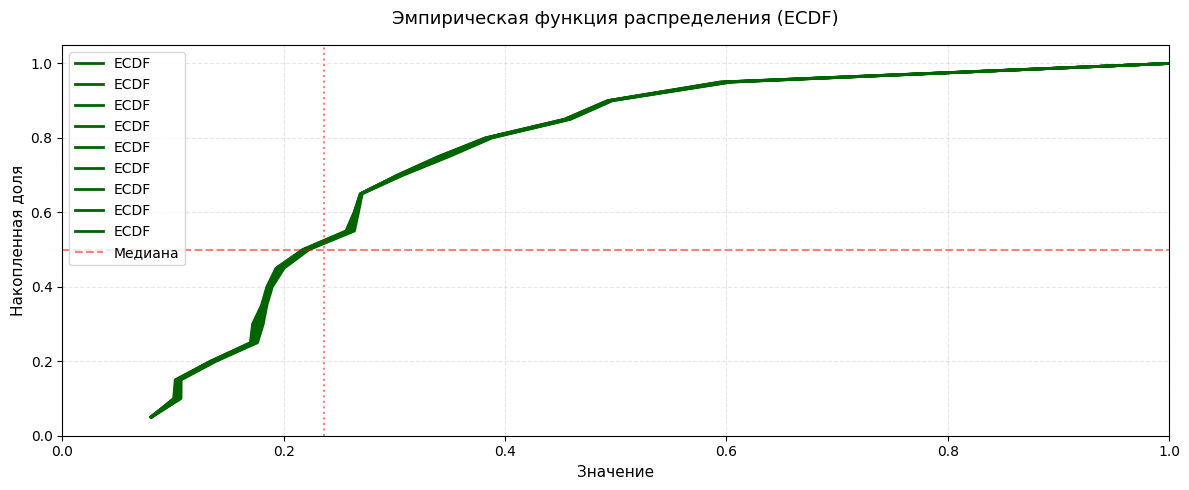

In [ ]:
plot_distribution_advanced(entropys, plot_type='ecdf')

In [ ]:
import json

with open('ilya_vocab.json', 'r') as file:
    reverse_vocab = json.load(file)

len(reverse_vocab)

115064

In [ ]:
vocab = {value: key for key, value in reverse_vocab.items()}

In [ ]:
vocab['the']

'98201'

In [ ]:
[p for p in ilya_phi[:, int(vocab['the'])]]

[np.float32(0.03263495),
 np.float32(1.6197154e-06),
 np.float32(2.169546e-23),
 np.float32(0.012601097),
 np.float32(0.019396048),
 np.float32(0.00078423554),
 np.float32(1.7684794e-14),
 np.float32(0.003958805),
 np.float32(0.000105620806),
 np.float32(0.019444648),
 np.float32(1.0724022e-09),
 np.float32(0.7035714),
 np.float32(0.0008065288),
 np.float32(0.0419324),
 np.float32(0.053624358),
 np.float32(1.1491047e-09),
 np.float32(2.1584758e-05),
 np.float32(0.057976536),
 np.float32(1.9953916e-07),
 np.float32(0.053139936)]

<BarContainer object of 20 artists>

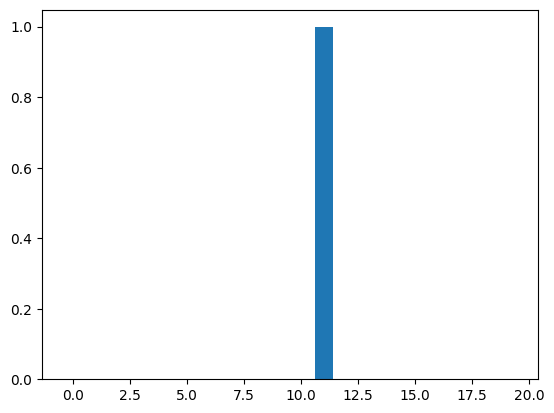

In [ ]:
plt.bar(range(20), ilya_phi[:, int(vocab['the'])])

In [ ]:
ilya_phi[ilya_phi > 0.99]

array([0.99999994, 0.9996753 , 0.9999999 , ..., 0.99999535, 1.        ,
       0.9966504 ], shape=(95764,), dtype=float32)

In [ ]:
mask = (ilya_phi > 0.99).any(axis=0)  # True для столбцов, содержащих хотя бы одну 1
result = ilya_phi[:, mask]          # выборка столбцов

In [ ]:
result.shape

(20, 95764)

In [ ]:
cols_idx = np.where(mask)[0]

In [ ]:
cols_idx

array([     0,      2,      3, ..., 115061, 115062, 115063],
      shape=(95764,))

In [ ]:
[reverse_vocab[str(i)] for i in cols_idx]

In [ ]:
import json

with open('phi_hist_vocab.json', 'r') as file:
    vocab = json.load(file)
len(vocab)
reverse_vocab = {value: key for key, value in vocab.items()}

In [ ]:
phi_hist = np.load('phi_hist.npy').T
phi_hist.shape

(100, 2052, 50)

Text(0.5, 1.0, 'hundred')

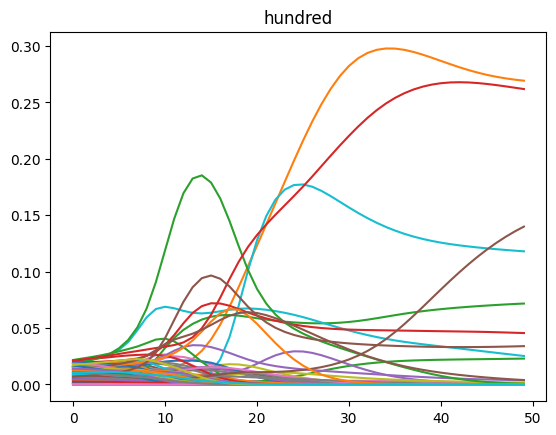

In [ ]:
token = 'hundred'
token_hist = [p for p in phi_hist[:, int(vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title(token)

Text(0.5, 1.0, 'super')

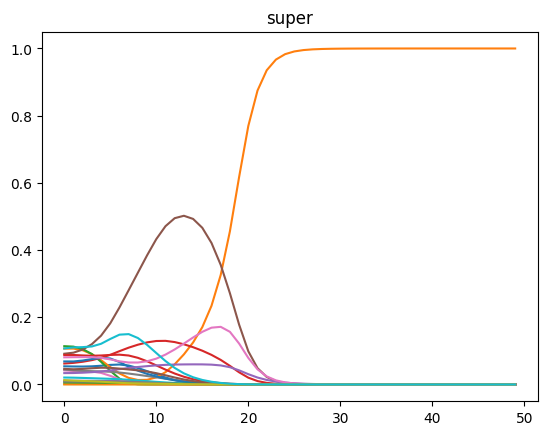

In [ ]:
token = 'super'
token_hist = [p for p in phi_hist[:, int(vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title(token)

[5.8638316e-33 8.1625375e-20 0.0000000e+00 4.7152620e-28 1.5622051e-29
 4.0739731e-24 0.0000000e+00 7.2167818e-20 3.4064221e-06 4.0946185e-25
 8.7493312e-01 6.1619000e-19 2.0787754e-13 6.9830892e-26 2.3391873e-20
 1.2483741e-01 2.2611898e-04 3.1190416e-25 1.6137779e-08 3.4462321e-22]


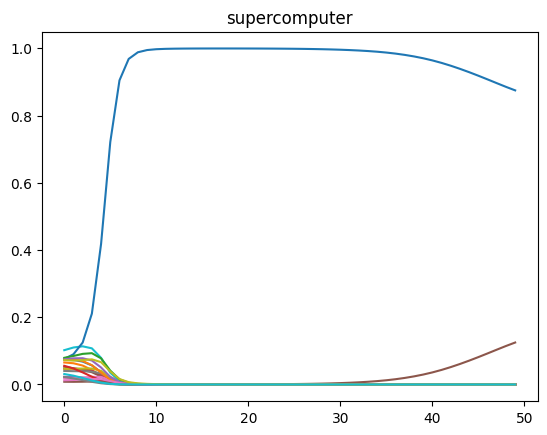

In [ ]:
token = 'supercomputer'
token_hist = [p for p in phi_hist[:, int(vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title(token)
print(phi_hist[:, int(vocab[token]), -1])

[9.9999988e-01 1.0404790e-34 0.0000000e+00 1.1526705e-31 6.1193036e-21
 3.0218429e-24 0.0000000e+00 5.9565694e-25 0.0000000e+00 1.5287781e-19
 7.0387746e-31 4.3782740e-18 3.7272332e-18 5.2997070e-08 1.5112174e-22
 4.3910945e-36 1.5557137e-29 7.9547648e-09 4.9982635e-39 2.6727180e-19]


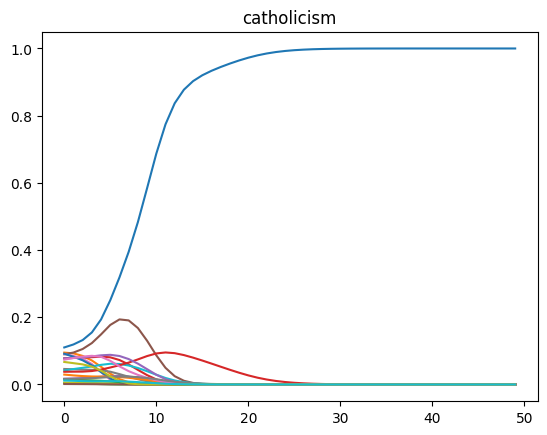

In [ ]:
token = 'catholicism'
token_hist = [p for p in phi_hist[:, int(vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title(token)
print(phi_hist[:, int(vocab[token]), -1])

Text(0.5, 1.0, 'the')

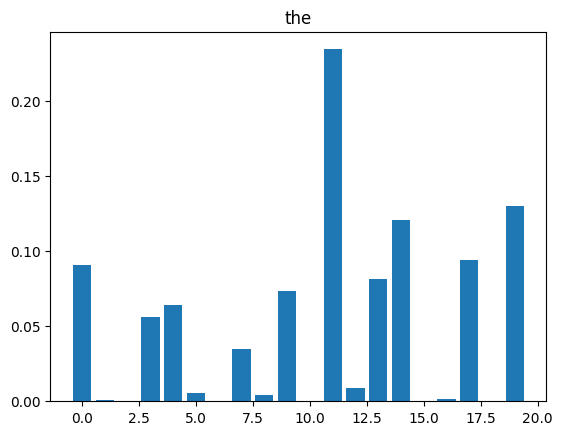

In [ ]:
token = 'the'
plt.bar(range(20), phi_hist[:, int(vocab[token]), 10])
plt.title(token)

Text(0.5, 1.0, 'super')

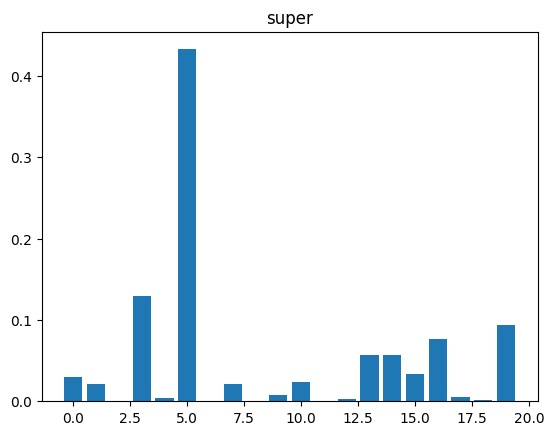

In [ ]:
token = 'super'
plt.bar(range(20), phi_hist[:, int(vocab[token]), 10])
plt.title(token)

Text(0.5, 1.0, 'supercomputer')

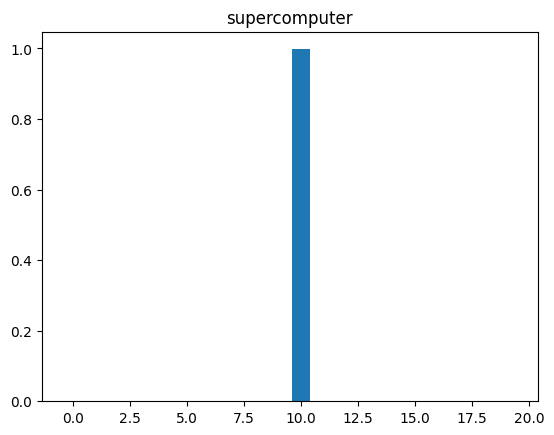

In [ ]:
token = 'supercomputer'
plt.bar(range(20), phi_hist[:, int(vocab[token]), 10])
plt.title(token)

In [ ]:
np.sum(phi_hist[:, :, -1], axis=1)
plt.bar(range(20), phi_hist[:, int(vocab['supercomputer']), 10])

array([ 6716.2603,  5183.4604,  1550.1204,  3549.8696,  5072.6025,
        2072.4297, 19100.52  ,  5127.8203,  7443.3047,  2674.2751,
       11594.847 ,  3505.0474,  3644.2246,  3395.1553,  4283.7974,
        9514.928 ,  5906.6733,  3856.6052,  8796.604 ,  2075.1763],
      dtype=float32)

In [ ]:
mask = (phi_hist[:, :, -1] > 0.99).any(axis=0)  # True для столбцов, содержащих хотя бы одну 1
result = phi_hist[:, mask, -1]         # выборка столбцов
result.shape

(20, 95763)

In [ ]:
cols_idx = np.where(mask)[0]
cols_idx

array([     0,      2,      3, ..., 115061, 115062, 115063],
      shape=(95763,))

Text(0.5, 1.0, 'Распределение якорных слов по темам')

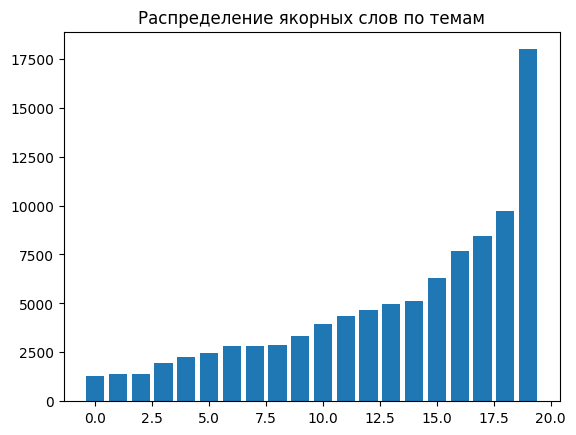

In [ ]:
plt.bar(range(20), np.sort(np.sum(result, axis=1)))
plt.title("Распределение якорных слов по темам")

In [32]:
import json

with open('/content/all_phi_hist_vocab.json', 'r') as file:
    all_vocab = json.load(file)
    all_reverse_vocab = {value: key for key, value in all_vocab.items()}

with open('/content/filtered_phi_hist_vocab.json', 'r') as file:
    filtered_vocab = json.load(file)
    filtered_reverse_vocab = {value: key for key, value in filtered_vocab.items()}

print(f"{len(all_vocab)=}")
print(f"{len(filtered_vocab)=}")

len(all_vocab)=115064
len(filtered_vocab)=30668


In [37]:
all_phi_hist = np.load('/content/all_phi_hist.npy').T
print(f"{all_phi_hist.shape=}")
filtered_phi_hist = np.load('/content/filtered_phi_hist.npy').T
print(f"{filtered_phi_hist.shape=}")

all_phi_hist.shape=(100, 115064, 50)
filtered_phi_hist.shape=(100, 30668, 50)


Text(0.5, 1.0, 'filtered good')

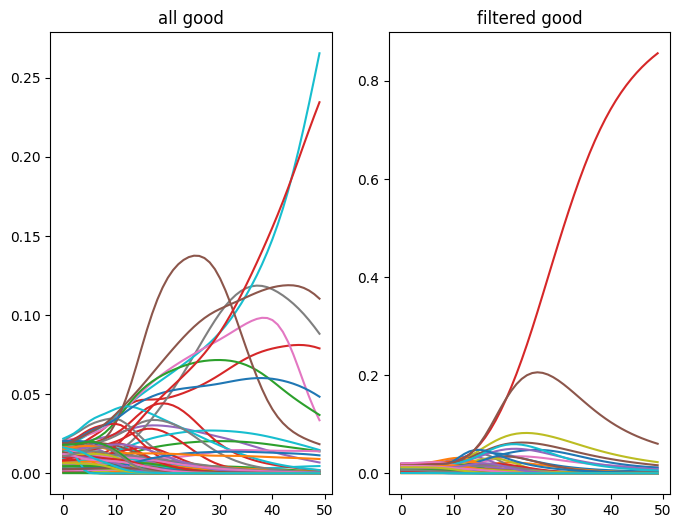

In [105]:
token = 'good'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))

all_token_hist = [p for p in all_phi_hist[:, int(all_vocab[token]), :]]
for i in range(len(all_token_hist)):
    ax1.plot(all_token_hist[i])
ax1.set_title('all ' + token)

filtered_token_hist = [p for p in filtered_phi_hist[:, int(filtered_vocab[token]), :]]
for i in range(len(filtered_token_hist)):
    ax2.plot(filtered_token_hist[i])
ax2.set_title('filtered ' + token)


Text(0.5, 1.0, 'filtered bad')

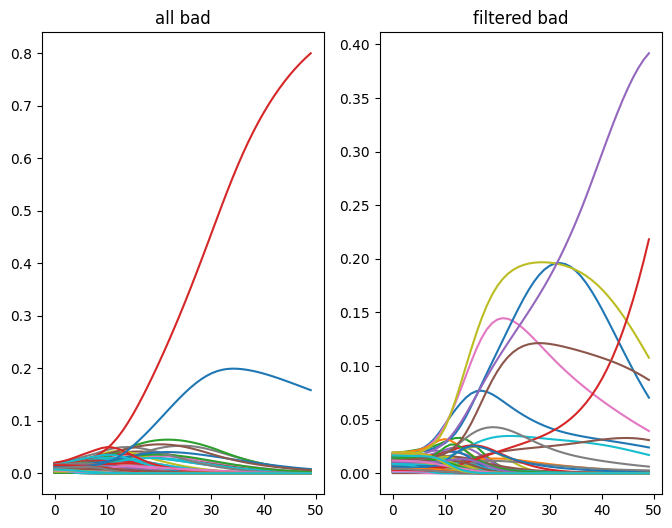

In [106]:
token = 'bad'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))

all_token_hist = [p for p in all_phi_hist[:, int(all_vocab[token]), :]]
for i in range(len(all_token_hist)):
    ax1.plot(all_token_hist[i])
ax1.set_title('all ' + token)

filtered_token_hist = [p for p in filtered_phi_hist[:, int(filtered_vocab[token]), :]]
for i in range(len(filtered_token_hist)):
    ax2.plot(filtered_token_hist[i])
ax2.set_title('filtered ' + token)


In [99]:
with open('/content/20ng_anchors_tfidf.json', 'r') as file:
    anchors_tfidf = json.load(file)
motorcycles_anchors = anchors_tfidf['rec.motorcycles']
motorcycles_anchors_ids = [all_vocab[anchor] for anchor in motorcycles_anchors]
sum_topics_motorcycles = np.sum(all_phi_hist[:, motorcycles_anchors_ids, -1], axis=1)
sum_topics_motorcycles[sum_topics_motorcycles > 0.5]

array([ 0.5723363 , 16.471954  ,  1.9189036 ,  1.        ,  2.91711   ,
        0.51553863,  0.7073983 ], dtype=float32)

In [100]:
with open('/content/20ng_anchors_tfidf.json', 'r') as file:
    anchors_tfidf = json.load(file)
space_anchors = anchors_tfidf['sci.space']
space_anchors_ids = [all_vocab[anchor] for anchor in space_anchors]
sum_space_topics = np.sum(all_phi_hist[:, space_anchors_ids, -1], axis=1)
sum_space_topics[sum_space_topics > .5]

array([ 2.2484927, 22.40228  ], dtype=float32)

In [101]:
with open('/content/20ng_anchors_tfidf.json', 'r') as file:
    anchors_tfidf = json.load(file)
mac_anchors = anchors_tfidf['comp.sys.mac.hardware']
mac_anchors_ids = [all_vocab[anchor] for anchor in mac_anchors]
sum_mac_topics = np.sum(all_phi_hist[:, mac_anchors_ids, -1], axis=1)
sum_mac_topics[sum_mac_topics > .5]

array([ 1.0078511,  1.0000815,  8.541531 , 12.270038 ,  1.0280062],
      dtype=float32)

In [109]:
mask = (all_phi_hist[:, :, -1] > 0.99).any(axis=0)  # True для столбцов, содержащих хотя бы одну 1
result = all_phi_hist[:, mask, -1]         # выборка столбцов
print(f"{result.shape=}")
print(f"{all_phi_hist.shape=}")

cols_idx = np.where(mask)[0]
print(f"{cols_idx=}")


result.shape=(100, 70107)
all_phi_hist.shape=(100, 115064, 50)
cols_idx=array([     3,      4,      5, ..., 115059, 115060, 115063],
      shape=(70107,))


Text(0.5, 1.0, 'Распределение якорных слов по темам')

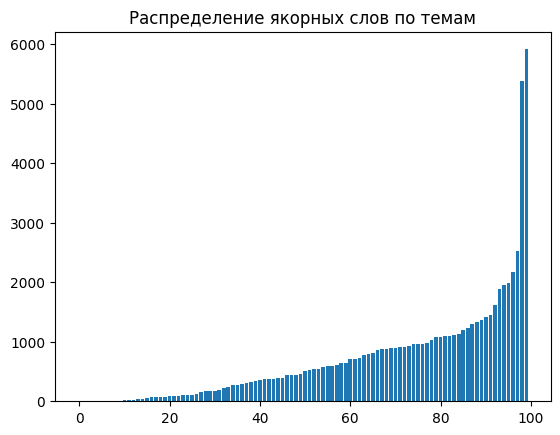

In [108]:
plt.bar(range(100), np.sort(np.sum(result, axis=1)))
plt.title("Распределение якорных слов по темам")